# code for analyzing differences between immediate & delayed recall

### imports

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, norm, normaltest, ttest_rel, wilcoxon

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_context('talk')

In [2]:
# try to show progress bars for long-running cells
# to properly show progress bars, you'll need to install tqdm,
# as well as widgetsnbextension and ipywidgets to render the element
try:
    from tqdm import tnrange, tqdm_notebook as tqdm
    from functools import partial
    gen = partial(tnrange, leave=False)
    show_pbars = True
except ModuleNotFoundError:
    print('To enable progress bars, install tqdm module (`pip install tqdm`)')
    gen = range
    show_pbars = False

### set paths

In [3]:
data_dir = '../../data'
ep_traj_dir = f'{data_dir}/models/episodes/trajectories'
ep_events_dir = f'{data_dir}/models/episodes/events'
rec_traj_dir = f'{data_dir}/models/recalls/trajectories'
rec_events_dir = f'{data_dir}/models/recalls/events'
pickle_dir = f'{data_dir}/pickles'
fig_dir = '../../paper/figures'

### load data

In [4]:
# episode trajectories
episode_traj = np.load(os.path.join(ep_traj_dir, 'atlep1_trajectory.npy'))

# episode events
episode_events = np.load(os.path.join(ep_events_dir, 'atlep1_events.npy'))

# recall trajectories
immediate_trajs = {}
for file in os.listdir(os.path.join(rec_traj_dir, 'atlep1')):
    if file.startswith('debug'):
        immediate_trajs[file.replace('.npy', '')] = np.load(os.path.join(rec_traj_dir, 'atlep1', file))
        
delayed_trajs = {}
for file in os.listdir(os.path.join(rec_traj_dir, 'delayed')):
    if file.startswith('debug'):
        delayed_trajs[os.path.splitext(file)[0]] = np.load(os.path.join(rec_traj_dir, 'delayed', file))
        
# average recall trajectories
avg_imm_traj = np.load(os.path.join(rec_traj_dir, 'atlep1', 'avg_trajectory.npy'))
avg_del_traj = np.load(os.path.join(rec_traj_dir, 'delayed', 'avg_trajectory.npy'))

# recall events
immediate_events = {}
for file in os.listdir(os.path.join(rec_events_dir, 'atlep1')):
    if file.startswith('debug'):
        immediate_events[file.replace('.npy', '')] = np.load(os.path.join(rec_events_dir, 'atlep1', file))
        
delayed_events = {}
for file in os.listdir(os.path.join(rec_events_dir, 'delayed')):
    if file.startswith('debug'):
        delayed_events[os.path.splitext(file)[0]] = np.load(os.path.join(rec_events_dir, 'delayed', file))
        
# average recall events
avg_imm_events = np.load(os.path.join(rec_events_dir, 'atlep1', 'avg_events.npy'))
avg_del_events = np.load(os.path.join(rec_events_dir, 'delayed', 'avg_events.npy'))

# episode-recall event mappings
imm_event_mappings = np.load(os.path.join(rec_events_dir, 'atlep1', 'event_mappings.npy'), allow_pickle=True)
del_event_mappings = np.load(os.path.join(rec_events_dir, 'delayed', 'event_mappings.npy'), allow_pickle=True)

# across-session ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

### functions

In [5]:
def r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value
    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [6]:
def z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value
    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

In [7]:
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values
    """
    return z2r(np.nanmean([r2z(r) for r in rs], axis=axis))

In [8]:
def corr_pearsonr(rs1, rs2):
    return pearsonr(r2z(np.array(rs1)), r2z(np.array(rs2)))

In [9]:
def annotate_corr(xy_data, r_loc, p_loc, stat_func=pearsonr, n_decimals=2, **kwargs):
    x_data, y_data = xy_data
    r_x, r_y = r_loc
    p_x, p_y = p_loc
        
    r, p = stat_func(x_data, y_data)
    r = f" = {str(round(r, n_decimals))}"
    
    min_p = float(f".{'0'*(n_decimals-1)}1")
    if p < min_p:
        p = f"<{min_p}"
    else:
        p = f" = {str(round(p, n_decimals))}"
        
    r_text = plt.text(r_x, r_y, f"$r{r}$", **kwargs)
    p_text = plt.text(p_x, p_y, f"$p{p}$", **kwargs)
    return r_text, p_text

In [10]:
# def corr_sigdiff_ind(r1n1, r2n2):
#     """
#     Function that performs Fisher (1925)'s test for comparison of two
#     correlation coefficients based on independent groups.
    
#     Parameters
#     ----------
#     r1n1, r2n2 : list-like
#         2-item iterables of (correlation coefficient, sample size)
#         for the two groups being compared
        
#     Returns
#     ----------
#     z : float
#         Test statistic
        
#     p : float
#         Two-tailed p-value
#     """
    
#     for arg in [r1n1, r2n2]:
#         if not hasattr(arg, '__iter__') or isinstance(arg, str):
#             raise TypeError("arguments should be list-like with len 2: \
#             (correlation coefficient, sample size)")
    
#     r1, n1 = r1n1
#     r2, n2 = r2n2
    
#     z = (r2z(r1) - r2z(r2)) / np.sqrt(1/(n1-3) + 1/(n2-3))
#     p = norm.sf(np.abs(z)) * 2 # two-sided
#     return (z, p)

In [11]:
# def corr_sigdiff_ind(r1n1, r2n2, n_obs1=None, n_obs2=None):
#     """
#     Function that returns the inverse z-transformed difference 
#     between two correlation coefficients from independent samples
#     of different sizes
    
#     Parameters
#     ----------
#     r1n1 : tup of floats or ndarray
#         sample 1's correlation value and number of observations
#     r2n2 : tup of floats or ndarray
#         sample 2's correlation value and number of observations
#     obs1 : int
#         if r1n1 and r2n2 are ndarrays, the number of observations that
#         went into calculating r1n1
#     obs2 : int
#         if r1n1 and r2n2 are ndarrays, the number of observations that
#         went into calculating r2n2
    
#     Returns
#     ----------
#     coff_diff : float
#         difference between correlation coefficients 
    
#     """
#     if isinstance(r1n1, np.ndarray) and isinstance(r2n2, np.ndarray):
#         Z_diff = (_r2z(r1n1) - _r2z(r2n2)) / np.sqrt(1/(n_obs1-3) + 1/(n_obs2-3))
        
    
#     elif isinstance(r1n1, tuple) and isinstance(r2n2, tuple):
#         r1, n1 = r1n1
#         r2, n2 = r2n2
#         Z_diff = _z2r((_r2z(r1) - _r2z(r2)) / np.sqrt(1/(n1-3) + 1/(n2-3)))
    
#     else:
#         raise ValueError("both arguments must be the same type")
        
#     return (Z_diff, norm.sf(abs(Z_diff))*2)

In [12]:
def ribbon(M, color='k', alpha=0.5, label=None):
    # for plotting 95% CI bars
    x = np.arange(M.shape[0])
    y = np.mean(M, axis=1)
    ci = 1.96 * np.divide(np.std(M, axis=1), np.sqrt(M.shape[1] - 1))
    
    h1 = plt.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color, label=label)
    return h1, h2

In [13]:
def bootstrap_ci(M, ci=95, n_boots=1000, color='#1f77b4', alpha=0.3, corrs=False, return_bounds=False, label=None, 
                prog_bar=show_pbars):
    evs = np.arange(M.shape[0])
    y = corr_mean(M, axis=1) if corrs else M.mean(axis=1)
    ci_low = (100 - ci) / 2
    ci_high = 100 - ci_low
    L, U = np.empty(evs.shape), np.empty(evs.shape)
    # constructs a single resample
    boot_mean = lambda x: np.random.choice(x, size=len(x), replace=True).mean()
    
    if prog_bar:
        evs_iter = tqdm(evs, leave=False)
    else:
        evs_iter = evs
        
    for ev in evs_iter:
        ev_dists = r2z(M[ev]) if corrs else M[ev]
        boot_iter = (boot_mean(ev_dists) for n in range(n_boots))
        boots = np.fromiter(boot_iter, dtype=np.float64)
        # use percentile bootstrap (seaborn default method)
        L[ev], U[ev] = np.percentile(boots, ci_low), np.percentile(boots, ci_high)
        if corrs:
            L[ev], U[ev] = z2r(L[ev]), z2r(U[ev])
    
    # error ribbons
    h1 = plt.fill_between(evs, L, U, color=color, alpha=alpha)
    # opaque line
    h2 = plt.plot(evs, y, color=color, label=label)
    returns = [h1, h2]
    if return_bounds:
        returns.extend([L, U])
    return returns

In [14]:
def bootstrap_ci_nan(M, ci=95, n_boots=1000, color='#1f77b4', alpha=0.3, corrs=False, return_bounds=False, label=None, 
                    prog_bar=show_pbars):
    evs = np.arange(M.shape[0])
    y = corr_mean(M, axis=1) if corrs else np.nanmean(M, axis=1)
    ci_low = (100 - ci) / 2
    ci_high = 100 - ci_low
    L, U = np.empty(evs.shape), np.empty(evs.shape)
    # constructs a single resample
    boot_mean = lambda x: np.random.choice(x, size=len(x), replace=True).mean()
    
    if prog_bar:
        evs_iter = tqdm(evs, leave=False)
    else:
        evs_iter = evs
        
    for ev in evs_iter:
        ev_dists = r2z(M[ev][~np.isnan(M[ev])]) if corrs else M[ev][~np.isnan(M[ev])]
        boot_iter = (boot_mean(ev_dists) for n in range(n_boots))
        boots = np.fromiter(boot_iter, dtype=np.float64)
        # use percentile bootstrap (seaborn default method)
        L[ev], U[ev] = np.percentile(boots, ci_low), np.percentile(boots, ci_high)
        if corrs:
            L[ev], U[ev] = z2r(L[ev]), z2r(U[ev])
    # error ribbons
    h1 = plt.fill_between(evs, L, U, color=color, alpha=alpha)
    # opaque line
    h2 = plt.plot(evs, y, color=color, label=label)
    returns = [h1, h2]
    if return_bounds:
        returns.extend([L, U])
    return returns

In [15]:
# # stashing correlation CI calcualtion for now -- wrong use case?
# def ribbon(M, color='k', alpha=0.5, label=None, corrs=False):    
#     x = np.arange(M.shape[0])
    
#     if corrs:
#         y = corr_mean(M, axis=1)
#     else:
#         y = np.mean(M, axis=1)
        
#     ci = 1.96 * np.divide(np.nanstd(M, axis=1), np.sqrt(M.shape[1] - 1))
        
#     h1 = plt.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)
#     h2 = plt.plot(x, y, color=color, label=label)
#     return h1, h2

In [16]:
def fill_precision_df(sub):
    imm_turkid = id_maps.loc[sub.name, 'session 1']
    del_turkid = id_maps.loc[sub.name, 'session 2']
    
    imm_mappings = imm_event_mappings[np.where(imm_event_mappings.T[0] == imm_turkid)].ravel()[1]
    del_mappings = del_event_mappings[np.where(del_event_mappings.T[0] == del_turkid)].ravel()[1]
    
    imm_corrs = np.diag(1 - cdist(immediate_events[imm_turkid], episode_events[imm_mappings], 'correlation'))
    del_corrs = np.diag(1 - cdist(delayed_events[del_turkid], episode_events[del_mappings], 'correlation'))
    
    for ix, ev in enumerate(imm_mappings):
        # inequalities except != with np.nan always return False
        if not sub.loc[(ev, 'immediate')] > imm_corrs[ix]:
            sub.loc[(ev, 'immediate')] = imm_corrs[ix]
            
    for ix, ev in enumerate(del_mappings):
        if not sub.loc[(ev, 'delayed')] > del_corrs[ix]:
            sub.loc[(ev, 'delayed')] = del_corrs[ix]
            
    for ev in range(n_events):
        sub.loc[(ev, 'change')] = sub.loc[(ev, 'immediate')] - sub.loc[(ev, 'delayed')]
        
    return sub 

# compare by timepoint

In [17]:
n_participants = id_maps.shape[0]
n_timepoints = episode_traj.shape[0]

### recall precision
How does participants' performance compare between immediate and delayed recall?

In [18]:
# # not as good a way? 
# # This is "precision of average participant," not "average precision across participants"

# immediate_corr = np.diag(1-cdist(avg_imm_traj, episode_traj, metric='correlation'))
# delayed_corr = np.diag(1-cdist(avg_del_traj, episode_traj, metric='correlation'))

In [19]:
# plt.plot(immediate_corr, color='red')
# plt.plot(delayed_corr, color='skyblue')
# plt.xlim(0, 1466)
# plt.ylim(0, 1)
# plt.tight_layout()
# plt.show()

In [20]:
imm_precision = np.zeros((n_participants, n_timepoints))
del_precision = np.zeros((n_participants, n_timepoints))

for ix, (_, subID) in enumerate(id_maps.iterrows()):
    imm_precision[ix] = np.diag(1 - cdist(immediate_trajs[subID['session 1']], episode_traj, 'correlation'))
    del_precision[ix] = np.diag(1 - cdist(delayed_trajs[subID['session 2']], episode_traj, 'correlation'))

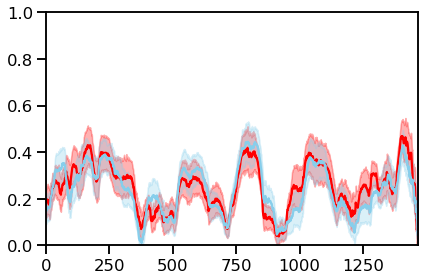

In [21]:
bootstrap_ci(imm_precision.T, color='red')
bootstrap_ci(del_precision.T, color='skyblue')
plt.xlim(0, n_timepoints-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### change in precision
How much information did participants lose (or gain) over the delay period?

In [22]:
precision_change = imm_precision - del_precision

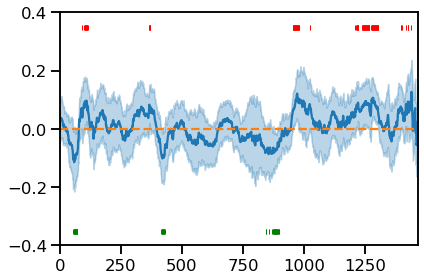

In [23]:
# red - tpts remembered better immediately
# green - tpts remembered better after delay
_, _, L, U = bootstrap_ci(precision_change.T, return_bounds=True)
sigmask_low = np.ma.masked_where(L <= 0, np.full_like(L, .35))
sigmask_high = np.ma.masked_where(U >= 0, np.full_like(U, -.35))
plt.plot(sigmask_low.filled(np.nan), linestyle='', marker='|', ms=5, color='red')
plt.plot(sigmask_high.filled(np.nan), linestyle='', marker='|', ms=5, color='green')
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_timepoints-1)
plt.ylim(-.4, .4)
plt.tight_layout()
plt.show()

### recall content variability across participants
How similar are participants' recall contents (to each other) in each session?

In [24]:
# currently using correlation between individual recall topic vector and average recall topic vector
# maybe better to do timepoint-wise standard deviation across participants, than average over topic dimensions?
imm_var = np.zeros((n_participants, n_timepoints))
del_var = np.zeros((n_participants, n_timepoints))

for ix, (_, subID) in enumerate(id_maps.iterrows()):
    imm_var[ix] = np.diag(1-cdist(immediate_trajs[subID['session 1']], avg_imm_traj, 'correlation'))
    del_var[ix] = np.diag(1-cdist(delayed_trajs[subID['session 2']], avg_del_traj, 'correlation'))

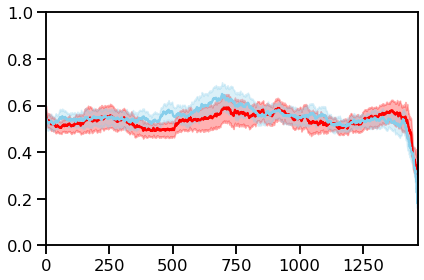

In [25]:
bootstrap_ci(imm_var.T, color='red')
bootstrap_ci(del_var.T, color='skyblue')
plt.xlim(0, n_timepoints-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### change in content variability across participants
Does participants' recall content converge or diverge over the delay period?

In [26]:
var_change = imm_var - del_var

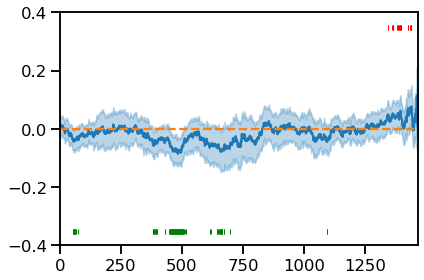

In [27]:
# red - tpts recalled more similarly immediately
# green - tpts recalled more similarly after delay
_, _, L, U = bootstrap_ci(var_change.T, return_bounds=True)
sigmask_low = np.ma.masked_where(L <= 0, np.full_like(L, .35))
sigmask_high = np.ma.masked_where(U >= 0, np.full_like(U, -.35))
plt.plot(sigmask_low.filled(np.nan), linestyle='', marker='|', ms=5, color='red')
plt.plot(sigmask_high.filled(np.nan), linestyle='', marker='|', ms=5, color='green')
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_timepoints-1)
plt.ylim(-.4, .4)
plt.tight_layout()
plt.show()

### recall precision variability across participants
How much variability is there are participants' memory performances for each session?

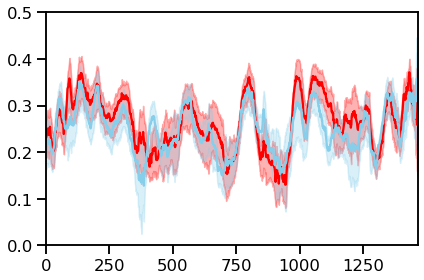

In [28]:
# standard deviation with 95% bootstrap CI's
imm_L, imm_U = np.empty(n_timepoints), np.empty(n_timepoints)
del_L, del_U = np.empty(n_timepoints), np.empty(n_timepoints)
boot_std = lambda x: np.random.choice(x, size=len(x), replace=True).std(ddof=1)

for tpt in gen(n_timepoints):
    imm_boot_iter = (boot_std(imm_precision.T[tpt]) for n in range(1000))
    del_boot_iter = (boot_std(del_precision.T[tpt]) for n in range(1000))
    imm_boots = np.fromiter(imm_boot_iter, dtype=np.float64)
    del_boots = np.fromiter(del_boot_iter, dtype=np.float64)
    imm_L[tpt], imm_U[tpt] = np.percentile(imm_boots, 2.5), np.percentile(imm_boots, 97.5)
    del_L[tpt], del_U[tpt] = np.percentile(del_boots, 2.5), np.percentile(del_boots, 97.5)

plt.fill_between(np.arange(n_timepoints), imm_L, imm_U, color='red', alpha=.3)
plt.plot(imm_precision.std(axis=0, ddof=1), color='red')
plt.fill_between(np.arange(n_timepoints), del_L, del_U, color='skyblue', alpha=.3)
plt.plot(del_precision.std(axis=0, ddof=1), color='skyblue')
plt.xlim(0, n_timepoints-1)
plt.ylim(0, .5)
plt.tight_layout()
plt.show()

### change in precision variability across participants
Does memory performance converge or diverge over the delay period?

//anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: RuntimeWarning: invalid value encountered in sqrt
  # Remove the CWD from sys.path while we load stuff.


//anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in sqrt
  


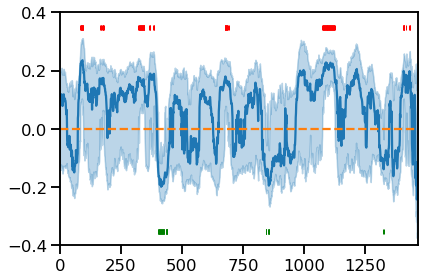

In [29]:
change_L, change_U = np.empty(n_timepoints), np.empty(n_timepoints)
# can't add/subtract standard deviations, have to use variance and then convert
boot_var_diff = lambda x,y: np.random.choice(x, size=len(x), replace=True).var(ddof=1) \
                            - np.random.choice(y, size=len(y), replace=True).var(ddof=1)

for tpt in gen(n_timepoints):
    vardiff_boot_iter = (boot_var_diff(imm_precision.T[tpt], del_precision.T[tpt]) for n in range(1000))
    vardiff_boots = np.fromiter(vardiff_boot_iter, dtype=np.float64)
    # convert to standard deviation, preserve negative differences
    stddiff_boots = np.where(vardiff_boots > 0, np.sqrt(vardiff_boots), np.negative(np.sqrt(np.abs(vardiff_boots))))
    change_L[tpt], change_U[tpt] = np.percentile(stddiff_boots, 2.5), np.percentile(stddiff_boots, 97.5)
    
mean_vardiff = imm_precision.var(axis=0, ddof=1) - del_precision.var(axis=0, ddof=1)
mean_stddiff = np.where(mean_vardiff > 0, np.sqrt(mean_vardiff), np.negative(np.sqrt(np.abs(mean_vardiff))))

plt.fill_between(np.arange(n_timepoints), change_L, change_U, color='#1f77b4', alpha=.3)
plt.plot(mean_stddiff, color='#1f77b4')
sigmask_low = np.ma.masked_where(change_L <= 0, np.full_like(change_L, .35))
sigmask_high = np.ma.masked_where(change_U >= 0, np.full_like(change_U, -.35))
plt.plot(sigmask_low.filled(np.nan), linestyle='', marker='|', ms=5, color='red')
plt.plot(sigmask_high.filled(np.nan), linestyle='', marker='|', ms=5, color='green')
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_timepoints-1)
plt.ylim(-.4, .4)
plt.tight_layout()
plt.show()

# compare by event

In [30]:
n_events = episode_events.shape[0]

In [31]:
# version using only best matched event
multiindex = pd.MultiIndex.from_product([list(range(episode_events.shape[0])), ['immediate', 'delayed', 'change']],
                                        names=['event', 'precision'])
event_precision = pd.DataFrame(index=multiindex, columns=id_maps.index, dtype=np.float64)

In [32]:
event_precision = event_precision.apply(fill_precision_df, result_type='broadcast')

In [33]:
event_precision.head()

MD-101218-A-01  MD-101218-B-01  MD-101218-A-02  \
event precision                                                   
0     immediate             NaN             NaN             NaN   
      delayed               NaN        0.603559             NaN   
      change                NaN             NaN             NaN   
1     immediate        0.656544             NaN             NaN   
      delayed               NaN             NaN             NaN   

                 MD-101218-B-02  MD-101218-A-03  MD-101218-B-03  \
event precision                                                   
0     immediate             NaN        0.648072             NaN   
      delayed               NaN             NaN             NaN   
      change                NaN             NaN             NaN   
1     immediate             NaN        0.775545             NaN   
      delayed          0.856236        0.685059        0.670832   

                 MD-101218-A-04  MD-101318-B-01  MD-101318-B-02  \
event precision                                                   
0     immediate             NaN             NaN             NaN   
      delayed               NaN             NaN             NaN   
      change                NaN             NaN             NaN   
1     immediate             NaN        0.644941             NaN   
      delayed               NaN        0.711414             NaN   

                 MD-101318-A-02  ...  MD-021519-A-01  MD-021819-B-01  \
event precision                  ...                                   
0     immediate             NaN  ...             NaN             NaN   
      delayed               NaN  ...             NaN             NaN   
      change                NaN  ...             NaN             NaN   
1     immediate             NaN  ...             NaN        0.918422   
      delayed          0.690108  ...        0.934212             NaN   

                 MD-021819-B-02  MD-021919-A-01  MD-021919-B-01  \
event precision                                                   
0     immediate             NaN             NaN             NaN   
      delayed               NaN             NaN             NaN   
      change                NaN             NaN             NaN   
1     immediate             NaN             NaN             NaN   
      delayed               NaN             NaN             NaN   

                 MD-021919-A-02  MD-022519-A-01  MD-022719-A-01  \
event precision                                                   
0     immediate             NaN             NaN             NaN   
      delayed               NaN             NaN        0.534845   
      change                NaN             NaN             NaN   
1     immediate             NaN        0.599945        0.686864   
      delayed               NaN             NaN             NaN   

                 MD-022819-B-01  MD-022819-B-02  
event precision                                  
0     immediate             NaN             NaN  
      delayed          0.555375             NaN  
      change                NaN             NaN  
1     immediate             NaN             NaN  
      delayed               NaN             NaN  

[5 rows x 57 columns]

### recall precision

In [34]:
imm_precision = event_precision.xs('immediate', level='precision')
del_precision = event_precision.xs('delayed', level='precision')

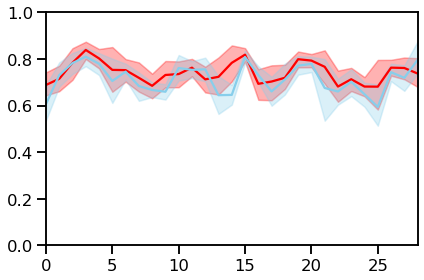

In [35]:
bootstrap_ci_nan(imm_precision.values, color='red')
bootstrap_ci_nan(del_precision.values, color='skyblue')
plt.xlim(0, n_events-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### change in precision

In [36]:
precision_change = event_precision.xs('change', level='precision').values

//anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: Mean of empty slice
  after removing the cwd from sys.path.


//anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: Mean of empty slice.
  if __name__ == '__main__':
//anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:85: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
//anaconda3/lib/python3.7/site-packages/numpy/lib/function_base.py:3826: RuntimeWarning: Invalid value encountered in percentile
  interpolation=interpolation)


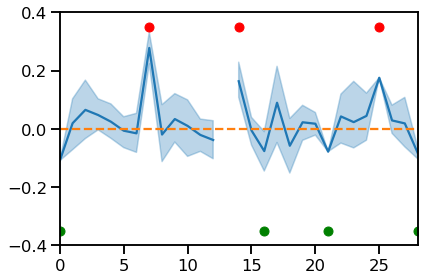

In [37]:
# red - events remembered better immediately
# green - events remembered better after delay
_, _, L, U = bootstrap_ci_nan(precision_change, return_bounds=True)

# avoid marking not-recalled events as significant
L, U = np.nan_to_num(L), np.nan_to_num(U)

sigmask_low = np.ma.masked_where(np.nan_to_num(L) <= 0, np.full_like(L, .35))
sigmask_high = np.ma.masked_where(np.nan_to_num(U) >= 0, np.full_like(U, -.35))
plt.plot(sigmask_low.filled(np.nan), linestyle='', marker='o', color='red')
plt.plot(sigmask_high.filled(np.nan), linestyle='', marker='o', color='green')
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_events-1)
plt.ylim(-.4, .4)
plt.tight_layout()
plt.show()

### recall content variability

In [38]:
imm_var = np.full((n_participants, n_events), np.nan)
del_var = np.full((n_participants, n_events), np.nan)

for ix, (_, subID) in enumerate(id_maps.iterrows()):
    ses1_id, ses2_id = subID.values
    imm_matches = imm_event_mappings[np.where(imm_event_mappings.T[0] == ses1_id)].ravel()[1]
    del_matches = del_event_mappings[np.where(del_event_mappings.T[0] == ses2_id)].ravel()[1]
    
    imm_var[ix, imm_matches] = np.diag(1-cdist(immediate_events[ses1_id], avg_imm_events[imm_matches], 'correlation'))
    del_var[ix, del_matches] = np.diag(1-cdist(delayed_events[ses2_id], avg_del_events[del_matches], 'correlation'))

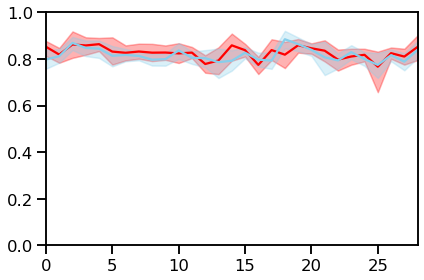

In [39]:
bootstrap_ci_nan(imm_var.T, color='red')
bootstrap_ci_nan(del_var.T, color='skyblue')
plt.xlim(0, n_events-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### change in content variability

In [40]:
var_change = imm_var - del_var

//anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: Mean of empty slice
  after removing the cwd from sys.path.


//anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: Mean of empty slice.
  if __name__ == '__main__':


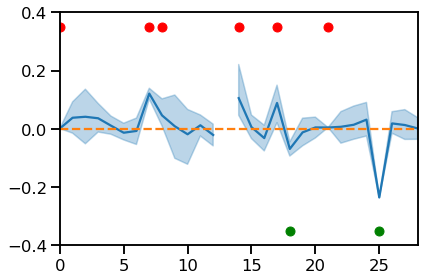

In [41]:
# red - events recalled more similarly immediately
# green - events recalled more similarly after delay
_, _, L, U = bootstrap_ci_nan(var_change.T, return_bounds=True)

# avoid marking not-recalled events as significant
L, U = np.nan_to_num(L), np.nan_to_num(U)

sigmask_low = np.ma.masked_where(L <= 0, np.full_like(L, .35))
sigmask_high = np.ma.masked_where(U >= 0, np.full_like(U, -.35))
plt.plot(sigmask_low.filled(np.nan), linestyle='', marker='o', color='red')
plt.plot(sigmask_high.filled(np.nan), linestyle='', marker='o', color='green')
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_events-1)
plt.ylim(-.4, .4)
plt.tight_layout()
plt.show()

### recall precision variability

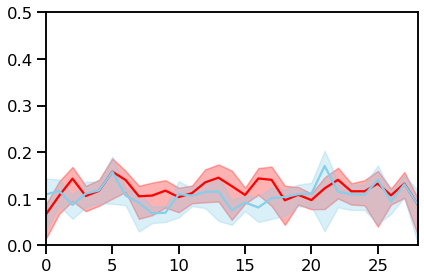

In [42]:
# standard deviation with 95% bootstrap CI's
imm_boots, del_boots = np.empty((1000, n_events)), np.empty((1000, n_events))
boot_std = lambda x: np.random.choice(x.dropna(), size=len(x.dropna()), replace=True).std(ddof=1)

for boot in gen(1000):
    imm_boots[boot] = imm_precision.apply(boot_std, axis=1).values
    del_boots[boot] = del_precision.apply(boot_std, axis=1).values

imm_L, imm_U = np.percentile(imm_boots, 2.5, axis=0), np.percentile(imm_boots, 97.5, axis=0)
del_L, del_U = np.percentile(del_boots, 2.5, axis=0), np.percentile(del_boots, 97.5, axis=0)

plt.fill_between(np.arange(n_events), imm_L, imm_U, color='red', alpha=.3)
plt.plot(imm_precision.std(axis=1, ddof=1), color='red')
plt.fill_between(np.arange(n_events), del_L, del_U, color='skyblue', alpha=.3)
plt.plot(del_precision.std(axis=1, ddof=1), color='skyblue')
plt.xlim(0, n_events-1)
plt.ylim(0, .5)
plt.tight_layout()
plt.show()

### change in precision variability

//anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in sqrt
  # This is added back by InteractiveShellApp.init_path()
//anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: invalid value encountered in sqrt
  from ipykernel import kernelapp as app


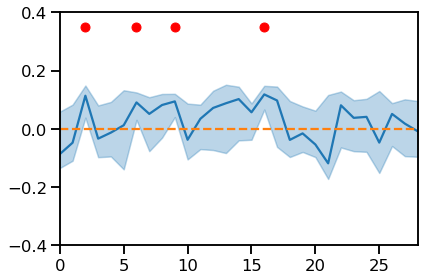

In [43]:
vardiff_boots = np.empty((1000, n_events))
# can't add/subtract standard deviations, have to use variance and then convert
boot_var = lambda x: np.random.choice(x.dropna(), size=len(x.dropna()), replace=True).var(ddof=1)
boot_var_diff = lambda df1,df2: df1.apply(boot_var, axis=1) - df2.apply(boot_var, axis=1)

for boot in gen(1000):
    vardiff_boots[boot] = boot_var_diff(imm_precision, del_precision)
    
    
# convert to standard deviation, preserve negative differences
stddiff_boots = np.where(vardiff_boots > 0, np.sqrt(vardiff_boots), np.negative(np.sqrt(np.abs(vardiff_boots))))
change_L, change_U = np.percentile(stddiff_boots, 2.5, axis=0), np.percentile(stddiff_boots, 97.5, axis=0)

mean_vardiff = imm_precision.var(axis=1, ddof=1) - del_precision.var(axis=1, ddof=1)
mean_stddiff = np.where(mean_vardiff > 0, np.sqrt(mean_vardiff), np.negative(np.sqrt(np.abs(mean_vardiff))))

plt.fill_between(np.arange(n_events), change_L, change_U, color='#1f77b4', alpha=.3)
plt.plot(mean_stddiff, color='#1f77b4')
sigmask_low = np.ma.masked_where(change_L <= 0, np.full_like(change_L, .35))
sigmask_high = np.ma.masked_where(change_U >= 0, np.full_like(change_U, -.35))
plt.plot(sigmask_low.filled(np.nan), linestyle='', marker='o', color='red')
plt.plot(sigmask_high.filled(np.nan), linestyle='', marker='o', color='green')
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_events-1)
plt.ylim(-.4, .4)
plt.tight_layout()
plt.show()

# compare number of events recalled between sessions

### total number of events

In [44]:
n_events = np.empty((2, n_participants))

for ix, (_, subID) in enumerate(id_maps.iterrows()):
    n_events[0, ix] = immediate_events[subID['session 1']].shape[0]
    n_events[1, ix] = delayed_events[subID['session 2']].shape[0]

In [45]:
n_events_imm, n_events_del = n_events
print(f'Average number of events recalled immediately: {n_events_imm.mean()}')
print(f'Average number of events recalled post-delay: {n_events_del.mean()}')
print(f'Average change in number of events recalled: {n_events_imm.mean() - n_events_del.mean()}')

Average number of events recalled immediately: 11.859649122807017
Average number of events recalled post-delay: 10.912280701754385
Average change in number of events recalled: 0.9473684210526319


In [46]:
ttest_rel(n_events_imm, n_events_del)

Ttest_relResult(statistic=2.1550797202615484, pvalue=0.035469878208777214)

In [47]:
wilcoxon(n_events_imm, n_events_del)

WilcoxonResult(statistic=366.5, pvalue=0.02212815442617563)

In [48]:
# is the distribution significantly non-normal?
print(f'immediate: {normaltest(n_events_imm)}')
print(f'delayed: {normaltest(n_events_del)}')

immediate: NormaltestResult(statistic=2.4369226460967934, pvalue=0.2956847804392545)
delayed: NormaltestResult(statistic=3.0334983379641054, pvalue=0.2194240392545469)


### number of _unique_ events

In [49]:
n_events_unique = np.empty((2, n_participants))

for ix, (_, subID) in enumerate(id_maps.iterrows()):
    imm_matches = imm_event_mappings[np.where(imm_event_mappings.T[0] == subID['session 1'])].ravel()[1]
    del_matches = del_event_mappings[np.where(del_event_mappings.T[0] == subID['session 2'])].ravel()[1]
    
    n_events_unique[0, ix] = np.unique(imm_matches).shape[0]
    n_events_unique[1, ix] = np.unique(del_matches).shape[0]

In [50]:
unique_events_imm, unique_events_del = n_events_unique
print(f'Average number of unique events recalled immediately: {unique_events_imm.mean()}')
print(f'Average number of unique events recalled post-delay: {unique_events_del.mean()}')
print(f'Average change in number of unique events recalled: {unique_events_imm.mean() - unique_events_del.mean()}')

Average number of unique events recalled immediately: 10.175438596491228
Average number of unique events recalled post-delay: 8.929824561403509
Average change in number of unique events recalled: 1.2456140350877192


In [51]:
ttest_rel(unique_events_imm, unique_events_del)

Ttest_relResult(statistic=3.2580708932897764, pvalue=0.0019087812207634386)

In [52]:
wilcoxon(unique_events_imm, unique_events_del)

WilcoxonResult(statistic=326.0, pvalue=0.0014711017321398432)

# relationships with memory performance & event memorability

In [53]:
stat_kwargs = {'ha' : 'left', 'fontsize' : 15}

### immediate vs delayed event memorability

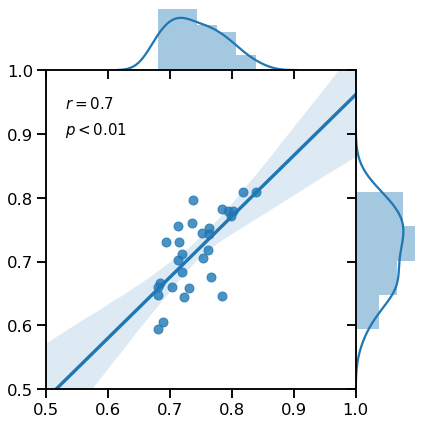

In [54]:
memorable_imm = imm_precision.mean(axis=1)
memorable_del = del_precision.mean(axis=1)

sns.jointplot(memorable_imm, memorable_del, kind='reg', space=0, xlim=(.5,1), ylim=(.5,1))
annotate_corr((memorable_imm, memorable_del), stat_func=pearsonr, r_loc=(.53,.94), p_loc=(.53,.9), **stat_kwargs)
plt.show()

### immediate memorability vs change in memorability

In [ ]:
memorable_change = memorable_imm - memorable_del

sns.jointplot(memorable_imm, memorable_change, kind='reg', space=0, xlim=(.5,1), ylim=(-.3,.3))
annotate_corr((memorable_imm, memorable_change), stat_func=pearsonr, r_loc=(.53,.23), p_loc=(.53,.19), 
              **stat_kwargs)
plt.show()

### immediate vs delayed memory performance

In [ ]:
imm_performance = imm_precision.mean()
del_performance = del_precision.mean()

sns.jointplot(imm_performance, del_performance, kind='reg', space=0, xlim=(.5,1), ylim=(.5,1))
annotate_corr((imm_performance, del_performance), stat_func=pearsonr, r_loc=(.53,.94), p_loc=(.53,.9), 
              **stat_kwargs)
plt.show()

### immediate performance vs change in performance

In [ ]:
# absolute change
performance_change = event_precision.xs('change', level='precision').mean()
# excldue participant with no shared events between sessions
imm_performance_inboth = imm_performance[performance_change.notna()]
performance_change = performance_change.dropna().reset_index(drop=True)

sns.jointplot(imm_performance_inboth, performance_change, kind='reg', space=0, xlim=(.5,1), ylim=(-.3,.3))
annotate_corr((imm_performance_inboth, performance_change), stat_func=pearsonr, r_loc=(.53,.23), p_loc=(.53,.19), 
             **stat_kwargs)
plt.show()

In [ ]:
# TO DO: FIND BETTER METHOD OF DOING THIS
# proportional change (make sure trend isn't regression toward mean)
performance_change_prop = performance_change.values / imm_performance_inboth.values

sns.jointplot(imm_performance_inboth, performance_change_prop, kind='reg', space=0, xlim=(.5,1), ylim=(-.3,.3))
annotate_corr((imm_performance_inboth, performance_change_prop), stat_func=pearsonr, r_loc=(.53,.23), p_loc=(.53,.19),
             **stat_kwargs)
plt.show()

### immediate vs delayed number of events

In [ ]:
sns.jointplot(n_events_imm, n_events_del, kind='reg', space=0, xlim=(0,25), ylim=(0,25))
annotate_corr((n_events_imm, n_events_del), stat_func=pearsonr, r_loc=(1.5,22), p_loc=(1.5, 20), 
              **stat_kwargs)
plt.show()

### immediate vs delayed number of _unique_ events

In [ ]:
sns.jointplot(unique_events_imm, unique_events_del, kind='reg', space=0, xlim=(0,20), ylim=(0,20))
annotate_corr((unique_events_imm, unique_events_del), stat_func=pearsonr, r_loc=(1,17.5), p_loc=(1, 15.5), 
              **stat_kwargs)
plt.show()